# **Boosting Techniques Assignment**

**1. What is Boosting in Machine Learning? Explain how it improves weak learners.**

-Boosting is an ensemble learning technique that combines multiple weak learners to create a strong predictive model. A weak learner is a model that performs slightly better than random guessing.
Boosting improves weak learners by training models sequentially. Each new model focuses more on the mistakes made by previous models. It assigns higher weights to misclassified samples, forcing subsequent models to learn those difficult cases. Over time, this reduces bias and improves overall accuracy.

**2. What is the difference between AdaBoost and Gradient Boosting in terms of how models are trained?**

-AdaBoost and Gradient Boosting differ mainly in how they train models:
- AdaBoost adjusts weights of misclassified samples and trains the next model with more focus on those samples.
- Gradient Boosting minimizes a loss function by fitting new models to the residual errors (gradients) of previous models.

Thus, AdaBoost focuses on sample weighting, while Gradient Boosting focuses on error correction using gradients.


**3. How does regularization help in XGBoost?**

-Regularization in XGBoost helps prevent overfitting by penalizing complex models. It uses both L1 (Lasso) and L2 (Ridge) regularization to control tree complexity, limit leaf weights, and reduce variance. This improves generalization and model robustness.

**4. Why is CatBoost considered efficient for handling categorical data?**

-CatBoost is efficient for categorical data because it uses ordered encoding and target statistics without requiring explicit preprocessing like one-hot encoding. It avoids overfitting by using permutations and handles categorical features natively, making it faster and more accurate.

**5. What are some real-world applications where boosting techniques are preferred over bagging methods?**

-Boosting is preferred in applications requiring high accuracy, such as:
- Fraud detection
- Credit risk prediction
- Medical diagnosis
- Recommendation systems
- Customer churn prediction

Boosting works better when reducing bias is important.


**6. Write a Python program to:**

**- Train an AdaBoost Classifier on the Breast Cancer dataset**

**- Print the model accuracy**

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = AdaBoostClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9649122807017544


**7. Write a Python program to:**

**- Train a Gradient Boosting Regressor on the California Housing dataset**

**- Evaluate performance using R-squared score**

In [3]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

X, y = fetch_california_housing(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.7756446042829697


**8. Write a Python program to:**

**- Train an XGBoost Classifier on the Breast Cancer dataset**

**- Tune the learning rate using GridSearchCV**

**- Print the best parameters and accuracy**

In [10]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

param_grid = {'learning_rate': [0.01, 0.1, 0.2]}

model = XGBClassifier(eval_metric='logloss')

grid = GridSearchCV(model, param_grid, cv=5)
grid.fit(X_train, y_train)

y_pred = grid.best_estimator_.predict(X_test)

print("Best Params:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))

Best Params: {'learning_rate': 0.2}
Accuracy: 0.956140350877193


**9. Write a Python program to:**

**- Train a CatBoost Classifier**

**- Plot the confusion matrix using seaborn**

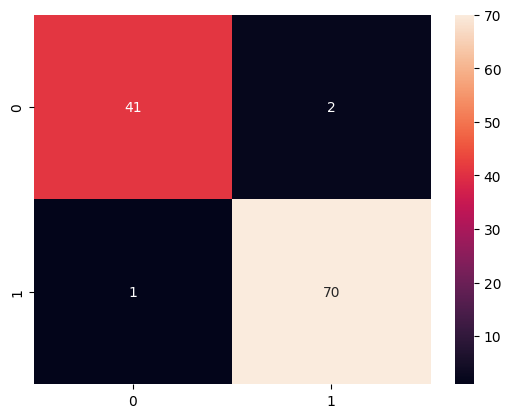

In [9]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from catboost import CatBoostClassifier
import seaborn as sns
import matplotlib.pyplot as plt

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = CatBoostClassifier(verbose=0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.show()

**10. You're working for a FinTech company trying to predict loan default using customer demographics and transaction behavior.The dataset is imbalanced, contains missing values, and has both numeric and categorical features.**

**Describe your step-by-step data science pipeline using boosting techniques:**
- Data preprocessing & handling missing/categorical values
- Choice between AdaBoost, XGBoost, or CatBoost
- Hyperparameter tuning strategy
- Evaluation metrics you'd choose and why
- How the business would benefit from your model



**-->** Ans:

1. Data Preprocessing:
Handle missing values using mean/median (numerical) and mode (categorical).
Encode categorical variables using Label Encoding or use CatBoost (no encoding needed).
Handle imbalance using SMOTE or class weights.
2. Model Choice:
Use CatBoost (best for categorical data) or XGBoost (high performance).
3. Hyperparameter Tuning:
Tune parameters like learning_rate, n_estimators, and max_depth using GridSearchCV or RandomizedSearchCV.
4. Evaluation Metrics:
Use F1-score, ROC-AUC (important for imbalanced data).
5. Business Benefit:
Helps reduce loan defaults, improves risk assessment, and increases profitability

In [8]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score
from xgboost import XGBClassifier

# Load sample dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# Model
model = XGBClassifier(scale_pos_weight=1, learning_rate=0.1, n_estimators=100)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

# Evaluation
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

F1 Score: 0.9805825242718447
ROC-AUC: 0.9973003694231316
